# Few-Shot Standard LLM Classifier - Qwen3-32B (Non-Thinking)

**Thesis:** Predicting Agentic Pull Request Rejection: An Empirical Comparison
of NLP Approaches

**Author**: Victoria Angela Vizmonte

This notebook is the full end-to-end pipeline for the Few-Shot Standard LLM
Classifier using Qwen3-32B in non-thinking mode via the OpenRouter API and DSPy.
Inference cells are cache-guarded and will load existing prediction CSVs without
rerunning the model. The evaluation section reproduces the full chart sequence
and saves all outputs to `results/final/qwen3_standard_llm/`.

| Item | Description |
|---|---|
| Model | Qwen3-32B (non-thinking mode) |
| OpenRouter model string | `qwen/qwen3-32b` |
| Thinking mode | Disabled (`enable_thinking=False`) |
| DSPy module | `dspy.Predict` (no chain-of-thought) |
| Temperature | 0.7 |
| top_p | 0.8 |
| top_k | 20 |
| Demo config | 10 manual demos: 5 rejected + 5 accepted; 1 PR per (agent, label) cell across all 5 agents, selected by proximity to per-cell median diff size |
| Diff budget | 16,000 characters per live PR; 4,000 characters per demo diff |
| Metadata version | Version 2 (includes related issue counts, test tracking, CI file tracking) |
| DSPy signature | `PRRejectionSignature` |
| Evaluation output | `results/final/qwen3_standard_llm/` |

In [1]:
# ---------------------------------------------------------------
# CONFIGURE THIS PATH before running any other cell.
# Set DRIVE_BASE to the folder on your Google Drive that contains
# data/, src/, results/, and requirements.txt for this project.
# Example: if you placed the shared folder at the root of your
# Drive, set this to '/content/drive/MyDrive/AgenticPRRejection'
# ---------------------------------------------------------------

from google.colab import drive
import subprocess, sys
from pathlib import Path

DRIVE_BASE = Path('/content/drive/MyDrive/Thesis/AgenticPRRejection')   # replace with your own path

# Mount Google Drive
drive.mount('/content/drive')
print("Drive mounted")

# Make src/ modules importable directly from Drive
sys.path.insert(0, f'{DRIVE_BASE}/src')
print("src/ added to path")

# Install dependencies
subprocess.run(
    ['pip', 'install', '-q', '-r',
     f'{DRIVE_BASE}/requirements.txt'],
    check=True
)
print("Dependencies installed")

Mounted at /content/drive
Drive mounted
src/ added to path
Dependencies installed


In [2]:
# Imports
import json
import logging
import os
import random
import re
import time
from pathlib import Path
from typing import Literal

import dspy
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import userdata
from IPython.display import display, display as ipy_display
from tqdm.auto import tqdm

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
)

from config import RANDOM_SEED
from data_loader import load_raw_tables
from evaluator import (
    compute_metrics, plot_metric_bars, plot_split_summary, save_metrics,
    display_metric_table_val, display_metric_table_test,
    plot_curves_summary, plot_diagnostics_summary,
    run_subgroup_report,
)
from features.metadata_features import (
    _compute_entropy,
    _detect_has_plan,
    _empty_description,
    _is_experimental_submission,
    _is_test_related,
    _touches_ci,
    _touches_config,
    _touches_tests,
)
from preprocessing import run_preprocessing
from splits import temporal_split

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(name)s — %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
)
logger = logging.getLogger(__name__)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'RANDOM_SEED: {RANDOM_SEED}')
print('Imports complete.')

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
08:35:03 - LiteLLM:WARNING: common_utils.py:979 - litellm: could not pre-load bedrock-runtime response stream shape — Bedrock event-stream decoding will be unavailable. Error: No module named 'botocore'
08:35:03 - LiteLLM:WARNING: common_utils.py:24 - litellm: could not pre-load sagemaker-runtime response stream shape — SageMaker event-stream decoding will be unavailable. Error: No module named 'botocore'


RANDOM_SEED: 42
Imports complete.


In [3]:
# API key setup
api_key = userdata.get('OPENROUTER_API_KEY')
if not api_key:
    raise RuntimeError(
        'OPENROUTER_API_KEY not found in Colab Secrets. '
        'Add it under Runtime > Manage secrets.'
    )
os.environ['OPENROUTER_API_KEY'] = api_key
print(f'API key loaded: {api_key[:8]}...')

API key loaded: sk-or-v1...


In [4]:
# Output paths
DRIVE_BASE = Path(DRIVE_BASE)
print(f'DRIVE_BASE set to: {DRIVE_BASE}')
print(f'Exists on Drive:   {DRIVE_BASE.exists()}')
RESULTS_BASE = DRIVE_BASE / 'results' / 'final' / 'qwen3_standard_llm'
MODELS_DIR   = RESULTS_BASE
EVAL_DIR     = RESULTS_BASE
RESULTS_BASE.mkdir(parents=True, exist_ok=True)
print(f'Results dir: {RESULTS_BASE}')

DRIVE_BASE set to: /content/drive/MyDrive/Thesis/AgenticPRRejection
Exists on Drive:   True
Results dir: /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/qwen3_standard_llm


In [5]:
# DSPy LM configuration (Qwen3-32B, non-thinking)
# The best-performing configuration on a 50-PR sample is used in this final model notebook.

OPENROUTER_HEADERS = {
    'HTTP-Referer': 'https://github.com/vikiviz/AgenticPRRejection',
    'X-Title': 'AgenticPRRejection Thesis',
}
M3_MODEL = 'openrouter/qwen/qwen3-32b'

lm_model3 = dspy.LM(
    model=M3_MODEL,
    api_key=api_key,
    api_base='https://openrouter.ai/api/v1',
    extra_headers=OPENROUTER_HEADERS,
    temperature=0.7,
    top_p=0.8,
    extra_body={
        'provider': {
            'sort': 'price',
            'allow_fallbacks': True,
        },
        'enable_thinking': False,  # disables Qwen3 thinking mode at API level
        'top_k': 20,
    },
)
dspy.configure(lm=lm_model3)
print('Exploratory LM configured: Qwen3-32B, non-thinking, temperature=0.7')
print(f'Model: {M3_MODEL}')


Exploratory LM configured: Qwen3-32B, non-thinking, temperature=0.7
Model: openrouter/qwen/qwen3-32b


## DSPy Signature

In [6]:
# DSPy Signature and Module

class PRRejectionSignature(dspy.Signature):
    """You are a code review assistant evaluating agentic pull requests submitted
    by AI coding agents to open-source repositories. Predict whether the PR
    will be rejected (closed without merge) using only submission-time information.
    Do not use post-submission information such as closed_at, time-to-merge,
    or reviewer reactions.

    Agentic PRs are rejected at ~33-35% for each split.
    Do not default to accepted. Use all available rejection signals across
    three domains: text, metadata, and diff.

    ### Text rejection signals
    - Blank, vague, or experimental PR description (e.g. 'testing', 'just trying',
      'experiment')
    - Title does not match the apparent scope of the diff
    - Description claims functionality not present or contradicted by the diff

    ### Metadata rejection signals
    - Is_experimental_submission=True or Empty_description=True
    - File_entropy = 0.0 is a mild acceptance signal (focused single-file change);
      File_entropy > 0 indicates multi-file changes with slightly higher rejection rates
    - Touches_tests=False with a functional diff
    - Related_issues=0 combined with a large or risky diff

    ### Diff rejection signals
    - Diffs of 100+ lines with no tests and no linked issue
    - No test file changes for a functional change
    - PR introduces bugs, breaks API compatibility, or disrupts existing functionality
    - The diff duplicates logic already visible in the surrounding code
    - Config-only or trivial changes with no clear value

    ### Predict accepted ONLY if ALL hold
    - Description clearly explains the change and its purpose
    - Diff is focused and directly addresses the stated intent
    - No experimental or tentative language in title or description

    If any acceptance condition is absent or unclear, predict rejected.

    Process: (1) Analyze text, metadata, and diff for the signals above.
    (2) Weight by predictive strength — experimental language and empty
    descriptions outweigh diff size. (3) Calibrate toward the ~33-35% baseline rejection rate.
    """

    title_and_description: str = dspy.InputField(
        desc='PR title and body. Flag experimental/tentative language, '
             'vague or empty descriptions, and mismatch between title and diff scope.'
    )
    metadata: str = dspy.InputField(
        desc='PR and repository metadata as key-value pairs. '
             'Prioritize: Is_experimental, Empty_description, Touches_tests, '
             'Related_issues, File_entropy.'
    )
    diff_text: str = dspy.InputField(
        desc='Git diff patch, truncated per file and globally. '
             'Flag: 100+ line diffs with no tests and no linked issue, '
             'text-code misalignment, duplicate implementation, '
             'and config-only or trivial changes.'
    )
    rejection_probability: str = dspy.OutputField(
        desc='Estimated probability that this PR will be rejected, on a scale '
             'from 0.0 to 1.0. Higher values mean more likely to be rejected. '
             '1.0 = certain rejection, 0.0 = certain acceptance. '
             'A value greater than or equal to 0.5 is classified as rejected, '
             'while less than 0.5 is classified as accepted. '
             'Do not invert this scale. '
             'Return a single decimal number to 4 decimal places only, '
             'e.g. 0.3471 or 0.7205. '
             'Do not copy probabilities from the examples. '
             'Generate your own independent probability based solely on this PR.'
    )
    prediction: Literal['accepted', 'rejected'] = dspy.OutputField(
        desc='accepted if the PR will be merged, rejected if it will be closed '
             'without merge. Derive this from your rejection_probability: '
             'predict rejected if rejection_probability >= 0.5.'
    )

class PRRejectionModule(dspy.Module):
    """DSPy module for PR rejection classification using dspy.Predict.

    Uses direct input-to-output prediction without reasoning traces.
    """

    def __init__(self) -> None:
        super().__init__()
        self.predictor = dspy.Predict(PRRejectionSignature)

    def forward(
        self,
        title_and_description: str,
        metadata: str,
        diff_text: str,
    ):
        return self.predictor(
            title_and_description=title_and_description,
            metadata=metadata,
            diff_text=diff_text,
        )


print('PRRejectionSignature and PRRejectionModule defined.')

PRRejectionSignature and PRRejectionModule defined.


## Input features

In [7]:
# Input formatting functions

def format_title_body(row: pd.Series) -> str:
    """Format PR title and body as a plain-text string.

    Args:
        row: A single row from a PR DataFrame with 'title' and 'body' columns.

    Returns:
        Formatted string with Title and Description sections.
    """
    title = str(row.get('title', '') or '')
    body = str(row.get('body', '') or '')
    return 'Title: ' + title + '\n\nDescription: ' + body


def format_metadata_text(row: pd.Series) -> str:
    """Format structured PR metadata as a plain-text key-value block.

    Uses the same field logic as PRMetadataEncoder (flags, entropy, plan
    detection) but outputs human-readable text instead of a numeric vector.

    Args:
        row: A single row from a PR DataFrame containing all metadata columns.

    Returns:
        Multiline string with one 'key: value' pair per line.
    """
    _fn = row.get('filenames')
    filenames = [f for f in _fn if isinstance(f, str)] if isinstance(_fn, (list, np.ndarray)) else []
    _fc = row.get('file_changes')
    file_changes = list(_fc) if isinstance(_fc, (list, np.ndarray)) else []
    ts = pd.to_datetime(row['created_at'])
    # Temporal features match Model 1's cyclic time encoding (hour_sin/cos, dow_sin/cos).
    # Raw strings are used here instead of sin/cos because the LLM reads text.
    lines = [
        'Language: ' + str(row.get('language', 'unknown')),
        'License: ' + str(row.get('license', 'unknown')),
        'Agent: ' + str(row.get('agent', 'unknown')),
        'Task type: ' + str(row.get('task_type', 'unknown')),
        'Stars: ' + str(int(row.get('stars', 0))),
        'Forks: ' + str(int(row.get('forks', 0))),
        'Additions: ' + str(int(row.get('total_additions', 0))),
        'Deletions: ' + str(int(row.get('total_deletions', 0))),
        'Files changed: ' + str(int(row.get('num_files_changed', 0))),
        'Commits: ' + str(int(row.get('num_commits', 0))),
        'Related issues: ' + str(int(row.get('related_issue_count', 0))),
        'Description length: ' + str(len(str(row.get('body', '') or ''))),
        'Has plan: ' + str(_detect_has_plan(row.get('body'))),
        'Touches CI: ' + str(_touches_ci(filenames)),
        'Touches tests: ' + str(
            _touches_tests(filenames)
            or _is_test_related(row.get('title'), row.get('body'), row.get('task_type'))
        ),
        'Touches config: ' + str(_touches_config(filenames)),
        'File entropy: ' + str(round(_compute_entropy(file_changes), 4)),
        'Is experimental: ' + str(_is_experimental_submission(row.get('title'), row.get('body'))),
        'Empty description: ' + str(_empty_description(row.get('body'))),
        'Submission hour: ' + str(ts.hour),
        'Submission day of week: ' + ts.day_name(),
    ]
    return '\n'.join(lines)


# Diff input constraints
# PER_FILE_LINE_CAP limits how many
# lines are taken from any single file before moving to the next.
# DIFF_TOKEN_BUDGET is the global cap across the entire PR diff.
# Token count is approximated as characters / 4, a standard
# approximation for code-heavy text.

PER_FILE_LINE_CAP = 200
DIFF_TOKEN_BUDGET = 4_000
DIFF_CHAR_BUDGET = DIFF_TOKEN_BUDGET * 4  # 16,000 characters (approx 4,000 tokens)

# Budget for demo diffs embedded in the few-shot prompt.
# Each inference prompt contains all 10 compiled demos plus the live PR,
# so a single prompt holds up to 11 diffs. Demo diffs use a smaller budget
# (4,000 chars each) to keep total prompt size manageable, while the live
# PR retains the full DIFF_CHAR_BUDGET (16,000 chars) for richer signal.

DEMO_DIFF_CHAR_BUDGET = 4_000  # 4,000 chars (approx 1000 tokens) per demo diff


def format_diff_text(row: pd.Series, diff_lookup: dict) -> str:
    """Format the full git diff for a PR as a plain-text string.

    Files are processed in the order they appear in the diff (file
    order within a commit, commit order within a PR). Each file's
    patch is capped at PER_FILE_LINE_CAP lines to ensure breadth
    across all changed files. The concatenated result is then capped
    at DIFF_CHAR_BUDGET characters (approx DIFF_TOKEN_BUDGET tokens).
    Token count is approximated at 4 characters per token.
    No content-based ranking is applied.

    Args:
        row: A single row from a PR DataFrame with an 'id' column.
        diff_lookup: Dict mapping pr_id to concatenated patch text.

    Returns:
        Diff string within the token budget, with truncation notes
        appended where applicable. Returns '[No diff available]'
        if no patch text exists for the PR.
    """
    pr_id = row['id']
    raw_diff = diff_lookup.get(pr_id, '')
    if not raw_diff or not raw_diff.strip():
        return '[No diff available]'

    # Split into per-file sections on 'diff --git' boundaries.
    file_sections = re.split(r'(?=diff --git )', raw_diff)
    file_sections = [s for s in file_sections if s.strip()]

    capped_sections = []
    for section in file_sections:
        lines = section.split('\n')
        if len(lines) > PER_FILE_LINE_CAP:
            lines = lines[:PER_FILE_LINE_CAP]
            lines.append(
                f'[File diff truncated at {PER_FILE_LINE_CAP} lines]'
            )
        capped_sections.append('\n'.join(lines))

    diff_text = '\n'.join(capped_sections)

    # Apply global token budget as a safety net across the full PR diff.
    if len(diff_text) > DIFF_CHAR_BUDGET:
        diff_text = diff_text[:DIFF_CHAR_BUDGET]
        diff_text += (
            f'\n\n[Diff truncated at ~{DIFF_TOKEN_BUDGET} tokens '
            f'({DIFF_CHAR_BUDGET} characters)]'
        )

    return diff_text if diff_text.strip() else '[No diff available]'


print('Input formatting functions defined.')
print(f'PER_FILE_LINE_CAP={PER_FILE_LINE_CAP}, DIFF_TOKEN_BUDGET={DIFF_TOKEN_BUDGET}, DIFF_CHAR_BUDGET={DIFF_CHAR_BUDGET}, DEMO_DIFF_CHAR_BUDGET={DEMO_DIFF_CHAR_BUDGET}')

Input formatting functions defined.
PER_FILE_LINE_CAP=200, DIFF_TOKEN_BUDGET=4000, DIFF_CHAR_BUDGET=16000, DEMO_DIFF_CHAR_BUDGET=4000


In [8]:
# Load preprocessed data
PROCESSED_PATH = DRIVE_BASE / 'data' / 'processed' / 'pr_closed.parquet'

if PROCESSED_PATH.exists():
    df = pd.read_parquet(PROCESSED_PATH)
    print(f'Loaded cached preprocessed data: {len(df):,} PRs')
else:
    print('Preprocessed file not found. Running preprocessing...')
    raw_tables = load_raw_tables(['pull_request', 'repository', 'pr_commits', 'pr_task_type'])
    df = run_preprocessing(raw_tables)
    df.to_parquet(PROCESSED_PATH, index=False)
    print(f'Preprocessing complete: {len(df):,} PRs saved to {PROCESSED_PATH}')

required_cols = [
    'id', 'label', 'title', 'body', 'created_at', 'language', 'agent',
    'stars', 'forks', 'total_additions', 'total_deletions',
    'num_files_changed', 'num_commits', 'related_issue_count',
    'filenames', 'file_changes', 'task_type',
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f'Preprocessed DataFrame is missing columns: {missing}. Re-run preprocessing.')

n_rejected = int(df['label'].sum())
n_accepted = len(df) - n_rejected
print(f'Total: {len(df):,} | Accepted: {n_accepted:,} | Rejected: {n_rejected:,} ({100 * n_rejected / len(df):.1f}%)')

Loaded cached preprocessed data: 10,648 PRs
Total: 10,648 | Accepted: 6,700 | Rejected: 3,948 (37.1%)


## Temporal split

In [9]:
# Temporal split (70/15/15 by PR creation date)
train_df, val_df, test_df = temporal_split(df)

for split_name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    rej_rate = 100 * split['label'].mean()
    print(f'{split_name:5s}: {len(split):,} PRs  ({rej_rate:.1f}% rejected)')

# Verify split sizes
_expected = {'train': 7453, 'val': 1598, 'test': 1597}
_actual = {'train': len(train_df), 'val': len(val_df), 'test': len(test_df)}
for _split, _exp in _expected.items():
    _act = _actual[_split]
    _status = 'OK' if _act == _exp else f'MISMATCH (expected {_exp})'
    print(f'  {_split}: {_act} [{_status}]')
if any(_actual[s] != _expected[s] for s in _expected):
    raise AssertionError(
        f'Split sizes do not match 70/15/15 configuration. '
        f'Got {_actual}. Update src/splits.py to use '
        f'train_frac=0.70, val_frac=0.15 before rerunning.'
    )
print('Split sizes verified: 70/15/15.')

train: 7,453 PRs  (38.3% rejected)
val  : 1,598 PRs  (33.0% rejected)
test : 1,597 PRs  (35.2% rejected)
  train: 7453 [OK]
  val: 1598 [OK]
  test: 1597 [OK]
Split sizes verified: 70/15/15.


In [10]:
# Load pr_commit_details and build diff lookup
all_pr_ids = set(df['id'].tolist())
tables = load_raw_tables(['pr_commit_details'])
commit_details = tables['pr_commit_details']
commit_details = commit_details[commit_details['pr_id'].isin(all_pr_ids)].copy()
del tables

print(f'pr_commit_details filtered: {len(commit_details):,} rows for {commit_details["pr_id"].nunique():,} PRs')

# Aggregate all patches per PR into a single string
diff_lookup: dict = (
    commit_details
    .groupby('pr_id')['patch']
    .apply(lambda patches: '\n'.join(p for p in patches if isinstance(p, str) and p.strip()))
    .to_dict()
)

n_with_diff = sum(1 for v in diff_lookup.values() if v)
median_chars = int(pd.Series([len(v) for v in diff_lookup.values() if v]).median())
print(f'Diff lookup built: {len(diff_lookup):,} entries, {n_with_diff:,} non-empty')
print(f'Median diff length: {median_chars:,} characters')
del commit_details

pr_commit_details filtered: 283,468 rows for 10,648 PRs
Diff lookup built: 10,648 entries, 10,648 non-empty
Median diff length: 7,259 characters


In [11]:
# Build formatted input columns for all splits
for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    rows_td, rows_meta, rows_diff = [], [], []
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc='Formatting ' + split_name):
        rows_td.append(format_title_body(row))
        rows_meta.append(format_metadata_text(row))
        rows_diff.append(format_diff_text(row, diff_lookup))
    split_df = split_df.copy()
    split_df['title_and_description'] = rows_td
    split_df['metadata_text'] = rows_meta
    split_df['diff_text'] = rows_diff
    if split_name == 'train':
        train_df = split_df
    elif split_name == 'val':
        val_df = split_df
    else:
        test_df = split_df

# Inspect a sample row
sample_row = val_df.iloc[0]
print('--- title_and_description (first 200 chars) ---')
print(sample_row['title_and_description'][:200])
print('\n--- metadata_text ---')
print(sample_row['metadata_text'])
print('\n--- diff_text (first 300 chars) ---')
print(sample_row['diff_text'][:300])

Formatting train:   0%|          | 0/7453 [00:00<?, ?it/s]

Formatting val:   0%|          | 0/1598 [00:00<?, ?it/s]

Formatting test:   0%|          | 0/1597 [00:00<?, ?it/s]

--- title_and_description (first 200 chars) ---
Title: Remove invocation confirmation for activePullRequest tool

Description: Removes the user confirmation prompt that was displayed when the `activePullRequest` tool needed to fetch coding agent se

--- metadata_text ---
Language: TypeScript
License: MIT
Agent: Copilot
Task type: refactor
Stars: 2421
Forks: 634
Additions: 1
Deletions: 9
Files changed: 1
Commits: 3
Related issues: 0
Description length: 1478
Has plan: False
Touches CI: False
Touches tests: False
Touches config: False
File entropy: 0.3251
Is experimental: False
Empty description: False
Submission hour: 17
Submission day of week: Monday

--- diff_text (first 300 chars) ---
@@ -33,15 +33,8 @@ export class ActivePullRequestTool implements vscode.LanguageModelTool<FetchIssu
 
 	async prepareInvocation(): Promise<vscode.PreparedToolInvocation> {
 		const pullRequest = this._findActivePullRequest();
-		let confirmationMessages: vscode.LanguageModelToolConfirmationMessages 


In [12]:
# Manual demo selection (5 rejected + 5 accepted, 10 demos total)

TARGET_AGENTS = ['Devin', 'Copilot', 'Cursor', 'Claude_Code', 'OpenAI_Codex']

train_df_copy = train_df.copy()
train_df_copy['diff_len_proxy'] = (
    train_df_copy['total_additions'].fillna(0) + train_df_copy['total_deletions'].fillna(0)
)

# For each (agent, label) cell, select the PR closest to the per-cell median
# diff size to avoid outlier diffs skewing the demo distribution.
all_rows = []
for agent in TARGET_AGENTS:
    for label_val, label_name in [(0, 'accepted'), (1, 'rejected')]:
        cell_df = train_df_copy[
            (train_df_copy['agent'] == agent) & (train_df_copy['label'] == label_val)
        ].copy()
        if cell_df.empty:
            print(f'  WARNING: No training PRs found for ({agent}, {label_name}) — skipping.')
            continue
        median_len = cell_df['diff_len_proxy'].median()
        cell_df['dist_to_median'] = (cell_df['diff_len_proxy'] - median_len).abs()
        cell_df = cell_df.sort_values(['dist_to_median', 'created_at'])
        selected = cell_df.iloc[0]
        all_rows.append({
            'agent': agent,
            'label': label_val,
            'label_name': label_name,
            'id': selected['id'],
            'diff_len_proxy': int(selected['diff_len_proxy']),
            '_row': selected,
        })

# Interleave accepted/rejected per agent so the model does not see all skewed demos last
selected_rows = all_rows

assert len([r for r in selected_rows if r['label'] == 1]) == 5, 'Expected 5 rejected demos'
assert len([r for r in selected_rows if r['label'] == 0]) == 5, 'Expected 5 accepted demos'

print(f'Total demo PRs selected: {len(selected_rows)} (5 rejected + 5 accepted)')
print('\nFinal demo summary:')
print(f'  {"Agent":<18} {"Label":<10} {"PR ID":<15} {"diff_len_proxy"}')
for r in selected_rows:
    print(f'  {r["agent"]:<18} {r["label_name"]:<10} {str(r["id"]):<15} {r["diff_len_proxy"]}')


Total demo PRs selected: 10 (5 rejected + 5 accepted)

Final demo summary:
  Agent              Label      PR ID           diff_len_proxy
  Devin              accepted   3077103096      127
  Devin              rejected   2787618893      208
  Copilot            accepted   3076300908      155
  Copilot            rejected   3087119059      167
  Cursor             accepted   3158063573      135
  Cursor             rejected   3176363924      258
  Claude_Code        accepted   3136804156      203
  Claude_Code        rejected   2889875255      636
  OpenAI_Codex       accepted   3070236675      45
  OpenAI_Codex       rejected   3075711443      83


## Demonstration construction

In [13]:
# Build manual DSPy demo examples
# rejection_probability must be included in demos. When this output field is absent
# from a demo dict, DSPy fills it with "Not supplied for this particular example."
# in the serialized prompt, and the LLM copies that string on its own outputs,
# causing parse failures.
# Per-demo indexing by list position gives one unique probability per demo slot,
# with a direct 1-to-1 mapping to the (agent, label) pair in each slot.

LABEL_MAP = {0: 'accepted', 1: 'rejected'}

# Rejected range: 0.55-0.90. Accepted range: 0.10-0.45.
DEMO_PROBS = [
    '0.4123',  # slot 0: Devin, accepted
    '0.7421',  # slot 1: Devin, rejected
    '0.3967',  # slot 2: Copilot, accepted
    '0.5834',  # slot 3: Copilot, rejected
    '0.2245',  # slot 4: Cursor, accepted
    '0.8903',  # slot 5: Cursor, rejected
    '0.2891',  # slot 6: Claude_Code, accepted
    '0.6178',  # slot 7: Claude_Code, rejected
    '0.1534',  # slot 8: OpenAI_Codex, accepted
    '0.8056',  # slot 9: OpenAI_Codex, rejected
]

manual_demos = []
for i, entry in enumerate(selected_rows):
    row = entry['_row']
    agent = entry['agent']
    label_val = entry['label']
    prob = DEMO_PROBS[i]
    demo = dspy.Example(
        title_and_description=format_title_body(row),
        metadata=format_metadata_text(row),
        diff_text=row['diff_text'][:DEMO_DIFF_CHAR_BUDGET],
        prediction=LABEL_MAP[label_val],
        rejection_probability=prob,
    ).with_inputs('title_and_description', 'metadata', 'diff_text')
    manual_demos.append(demo)
    print(
        f'  Demo {len(manual_demos):>2}: agent={agent:<15} '
        f'label={LABEL_MAP[label_val]:<8} '
        f'rejection_probability={prob}'
    )

n_acc = sum(1 for e in manual_demos if e.prediction == 'accepted')
n_rej = sum(1 for e in manual_demos if e.prediction == 'rejected')
print(f'\nBuilt {len(manual_demos)} manual demos: {n_acc} accepted, {n_rej} rejected.')
print('DEMO_PROBS: per-demo indexed, 5/5 balanced (interleaved per agent, accepted then rejected).')
print(f'Demo diffs capped to DEMO_DIFF_CHAR_BUDGET={DEMO_DIFF_CHAR_BUDGET} chars.')
_cache_to_delete = MODELS_DIR / 'qwen3_standard_llm_compiled_program.json'
if _cache_to_delete.exists():
    os.remove(_cache_to_delete)
    print(f'Deleted stale cache: {_cache_to_delete}')


  Demo  1: agent=Devin           label=accepted rejection_probability=0.4123
  Demo  2: agent=Devin           label=rejected rejection_probability=0.7421
  Demo  3: agent=Copilot         label=accepted rejection_probability=0.3967
  Demo  4: agent=Copilot         label=rejected rejection_probability=0.5834
  Demo  5: agent=Cursor          label=accepted rejection_probability=0.2245
  Demo  6: agent=Cursor          label=rejected rejection_probability=0.8903
  Demo  7: agent=Claude_Code     label=accepted rejection_probability=0.2891
  Demo  8: agent=Claude_Code     label=rejected rejection_probability=0.6178
  Demo  9: agent=OpenAI_Codex    label=accepted rejection_probability=0.1534
  Demo 10: agent=OpenAI_Codex    label=rejected rejection_probability=0.8056

Built 10 manual demos: 5 accepted, 5 rejected.
DEMO_PROBS: per-demo indexed, 5/5 balanced (interleaved per agent, accepted then rejected).
Demo diffs capped to DEMO_DIFF_CHAR_BUDGET=4000 chars.
Deleted stale cache: /content/drive

In [14]:
# Inject manual demos into PRRejectionModule

M3_PROGRAM_PATH = MODELS_DIR / 'qwen3_standard_llm_compiled_program.json'

if M3_PROGRAM_PATH.exists():
    compiled_model3 = PRRejectionModule()
    compiled_model3.load(str(M3_PROGRAM_PATH))
    print(f'Loaded compiled program from cache: {M3_PROGRAM_PATH}')
else:
    compiled_model3 = PRRejectionModule()
    compiled_model3.predictor.demos = manual_demos
    compiled_model3.save(str(M3_PROGRAM_PATH))
    print(f'Manual demos injected and saved to {M3_PROGRAM_PATH}')
    print(f'  {sum(1 for d in manual_demos if d.prediction == "accepted")} accepted, '
          f'{sum(1 for d in manual_demos if d.prediction == "rejected")} rejected.')

dspy.configure(lm=lm_model3)

Manual demos injected and saved to /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/qwen3_standard_llm/qwen3_standard_llm_compiled_program.json
  5 accepted, 5 rejected.


In [15]:
# Inspect demos

with open(str(M3_PROGRAM_PATH)) as _f_inspect:
    _prog_inspect = json.load(_f_inspect)

_demos = _prog_inspect.get('predictor', {}).get('demos', [])
print(f'Number of bootstrapped demos: {len(_demos)}\n')

for i, demo in enumerate(_demos):
    print(f'--- Demo {i + 1} ---')
    print(f'  prediction:            {demo.get("prediction", "MISSING")}')
    print(f'  rejection_probability: {demo.get("rejection_probability", "MISSING")}')
    prob_val = str(demo.get('rejection_probability', ''))
    if 'not supplied' in prob_val.lower():
        print('  WARNING: DSPy placeholder string detected — delete cache and recompile.')
    # rejection_probability absent from demos is intentional — LLM generates it freely at inference.
    td = demo.get('title_and_description', '')
    print(f'  title_and_description ({len(td)} chars): {td[:120].strip()}...')
    meta = demo.get('metadata', '')
    meta_lines = meta.split(chr(10))
    agent_line = next((l for l in meta_lines if l.startswith('Agent:')), 'Agent: NOT FOUND')
    print(f'  metadata ({len(meta)} chars): first line: {meta_lines[0]}')
    print(f'  {agent_line}')
    diff = demo.get('diff_text', '')
    print(f'  diff_text ({len(diff)} chars): {diff[:120].strip()}...')
    if len(diff) > DEMO_DIFF_CHAR_BUDGET:
        print(f'  WARNING: demo diff exceeds DEMO_DIFF_CHAR_BUDGET ({DEMO_DIFF_CHAR_BUDGET} chars) — delete cache and recompile.')
    print()

Number of bootstrapped demos: 10

--- Demo 1 ---
  prediction:            accepted
  rejection_probability: 0.4123
  title_and_description (906 chars): Title: Fix: Concatenate metadata arrays into strings with exceptions

Description: # Fix: Only concatenate description f...
  metadata (386 chars): first line: Language: TypeScript
  Agent: Devin
  diff_text (4000 chars): @@ -128,17 +128,30 @@ pub unsafe extern "C" fn extract_metadata(html: *const libc::c_char) -> *mut lib
             if l...

--- Demo 2 ---
  prediction:            rejected
  rejection_probability: 0.7421
  title_and_description (603 chars): Title: feat(intelligence): add tests for AI agent default config endpoint

Description: # AI Agent Default Config Tests...
  metadata (388 chars): first line: Language: JavaScript
  Agent: Devin
  diff_text (4000 chars): @@ -5,29 +5,40 @@
  */
 
 import getProp from 'lodash/get';
-import type { QuestionType } from '@box/box-ai-content-answ...

--- Demo 3 ---
  prediction:         

In [16]:
# Run predictions function
REQUEST_DELAY_SECONDS = 0.5


def parse_rejection_probability(raw: str | None) -> tuple[float, bool]:
    """Extract a float probability from a potentially verbose LLM output string."""
    if raw is None or not isinstance(raw, str):
        logger.warning("Unparseable rejection_probability raw=%r, returning fallback 0.5", raw)
        return 0.5, True
    cleaned = raw.strip()
    if cleaned.endswith('%'):
        try:
            prob = float(cleaned[:-1]) / 100.0
            return max(0.0, min(1.0, prob)), False
        except ValueError:
            pass
    match = re.search(r'\b(1\.0+|0?\.\d+|[01])\b', cleaned)
    if match:
        return max(0.0, min(1.0, float(match.group(1)))), False
    try:
        prob = float(cleaned)
        return max(0.0, min(1.0, prob)), False
    except (ValueError, TypeError):
        pass
    logger.warning("Unparseable rejection_probability raw=%r, returning fallback 0.5", raw)
    return 0.5, True


def run_predictions(
    compiled_program: dspy.Module,
    split_df: pd.DataFrame,
    split_name: str,
    output_dir: Path,
    partial_path: Path | None = None,
) -> pd.DataFrame:
    """Run inference on a split DataFrame and return a predictions DataFrame.

    Partial results are flushed to disk every 100 rows so that a Colab session
    timeout does not lose completed predictions. Failed rows receive a
    rejection_probability of 0.5 (uninformative prior) and raw_prediction of
    'unknown'. If the failure rate is high, note it as a thesis limitation.

    Args:
        compiled_program: DSPy compiled predictor (BootstrapFewShot output).
        split_df: DataFrame for the split (val or test), with pre-built
            title_and_description, metadata_text, and diff_text columns.
        split_name: 'val' or 'test', used in the progress bar and partial filename.
        output_dir: Directory to write partial CSVs for session-loss resilience.

    Returns:
        DataFrame with columns: pr_id, label, raw_prediction,
        rejection_probability, y_pred (binarized at threshold=0.5).
    """
    if partial_path is None:
        partial_path = output_dir / ('predictions_' + split_name + '_partial.csv')
    records = []
    n_failures = 0
    n_parse_fallbacks = 0

    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=split_name):
        try:
            result = compiled_program(
                title_and_description=row['title_and_description'],
                metadata=row['metadata_text'],
                diff_text=row['diff_text'],
            )
            raw_pred = result.prediction.lower().strip()
            prob, is_fallback = parse_rejection_probability(result.rejection_probability)
            if is_fallback:
                n_parse_fallbacks += 1
                logger.warning(
                    "Fallback prob=0.5 for pr_id=%s; raw rejection_probability=%r",
                    row['id'],
                    result.rejection_probability,
                )
        except Exception as e:
            logger.warning('Prediction failed for pr_id=%s: %s', row['id'], e)
            raw_pred = 'unknown'
            prob = 0.5
            n_failures += 1

        records.append({
            'pr_id': row['id'],
            'label': int(row['label']),
            'raw_prediction': raw_pred,
            'rejection_probability': prob,
            'y_pred': int(prob >= 0.5),
        })
        time.sleep(REQUEST_DELAY_SECONDS)

        if len(records) % 25 == 0:
            pd.DataFrame(records).to_csv(partial_path, index=False)
            logger.info('Partial save: %d/%d rows written to %s', len(records), len(split_df), partial_path)

    result_df = pd.DataFrame(records)
    print(f'{split_name}: {n_failures}/{len(split_df)} API failures  |  {n_parse_fallbacks}/{len(split_df)} parse fallbacks')
    return result_df


print(f'run_predictions defined. REQUEST_DELAY_SECONDS={REQUEST_DELAY_SECONDS}')

run_predictions defined. REQUEST_DELAY_SECONDS=0.5


## 50-PR tuning

In [17]:
# 50-PR tuning sample inference

TUNING_N = 50
TUNING_PRED_PATH = MODELS_DIR / 'qwen3_standard_llm_predictions_tuning_50pr.csv'
TUNING_PARTIAL_PATH = MODELS_DIR / 'qwen3_standard_llm_predictions_tuning_50pr_partial.csv'

dspy.configure(lm=lm_model3)

if TUNING_PRED_PATH.exists():
    tuning_preds = pd.read_csv(TUNING_PRED_PATH)
    print(f'Loaded cached tuning predictions: {len(tuning_preds)} rows')
else:
    tuning_sample = val_df.sample(n=TUNING_N, random_state=RANDOM_SEED)
    print(f'Tuning sample: {len(tuning_sample)} PRs '
          f'({tuning_sample["label"].sum()} rejected, '
          f'{(tuning_sample["label"]==0).sum()} accepted)')

    tuning_preds = run_predictions(compiled_model3, tuning_sample, 'tuning_50pr', MODELS_DIR, partial_path=TUNING_PARTIAL_PATH)
    tuning_preds.to_csv(TUNING_PRED_PATH, index=False)
    print(f'Saved tuning predictions: {TUNING_PRED_PATH}')


Loaded cached tuning predictions: 50 rows


In [18]:
# Evaluate 50-PR tuning sample

y_true = tuning_preds['label'].values
y_pred = tuning_preds['y_pred'].values
y_prob = tuning_preds['rejection_probability'].values

metrics = {
    'precision': precision_score(y_true, y_pred, zero_division=0),
    'recall':    recall_score(y_true, y_pred, zero_division=0),
    'f1':        f1_score(y_true, y_pred, zero_division=0),
    'pr_auc':    average_precision_score(y_true, y_prob),
    'roc_auc':   roc_auc_score(y_true, y_prob),
}

print('Qwen3-32B non-thinking | 50-PR tuning sample results:')
print(f'  Precision : {metrics["precision"]:.4f}')
print(f'  Recall    : {metrics["recall"]:.4f}')
print(f'  F1        : {metrics["f1"]:.4f}')
print(f'  PR-AUC    : {metrics["pr_auc"]:.4f}')
print(f'  ROC-AUC   : {metrics["roc_auc"]:.4f}')
print()
print('Probability distribution:')
print(pd.Series(y_prob).describe().round(4))
print()
unique_probs = len(pd.Series(y_prob).unique())
print(f'Unique probability values: {unique_probs} / {len(y_prob)}')

# Save metrics
with open(MODELS_DIR / 'qwen3_standard_llm_metrics_tuning_50pr.json', 'w') as f:
    json.dump(metrics, f, indent=2)


Qwen3-32B non-thinking | 50-PR tuning sample results:
  Precision : 0.3333
  Recall    : 0.3636
  F1        : 0.3478
  PR-AUC    : 0.4285
  ROC-AUC   : 0.5361

Probability distribution:
count    50.0000
mean      0.3688
std       0.2605
min       0.1234
25%       0.1234
50%       0.2864
75%       0.4552
max       0.9214
dtype: float64

Unique probability values: 29 / 50


## Full validation inference

In [19]:
# Full val inference
# Runs Qwen3-32B non-thinking on the full validation set (~1,598 PRs).
# The 50-PR tuning sample predictions are merged in to avoid re-running
# those 50 PRs. A resume mechanism loads any partial predictions already
# written to disk so that a Colab session timeout does not restart
# inference from scratch.
# If you would like to rerun inference, please delete the prediction CSVs from the results folder.

VAL_PRED_PATH = MODELS_DIR / 'qwen3_standard_llm_predictions_val.csv'
VAL_PARTIAL_PATH = MODELS_DIR / 'qwen3_standard_llm_predictions_val_partial.csv'

dspy.configure(lm=lm_model3)

if VAL_PRED_PATH.exists():
    val_preds = pd.read_csv(VAL_PRED_PATH)
    print(f'Loaded cached full val predictions: {len(val_preds)} rows')
else:
    # Build the set of PR IDs already predicted
    # Start from tuning sample predictions (50 PRs).
    tuning_ids = set(tuning_preds['pr_id'].tolist())

    # Load partial predictions from a previous interrupted run if present.
    if VAL_PARTIAL_PATH.exists():
        partial_df = pd.read_csv(VAL_PARTIAL_PATH)
        partial_ids = set(partial_df['pr_id'].tolist())
        print(f'Resuming: loaded {len(partial_df)} partial predictions from {VAL_PARTIAL_PATH}')
    else:
        partial_df = pd.DataFrame()
        partial_ids = set()
        print('No partial predictions found — starting fresh.')

    already_predicted = tuning_ids | partial_ids

    # Identify remaining PRs to predict
    val_remaining = val_df[
        ~val_df['id'].isin(already_predicted)
    ].reset_index(drop=True)

    print(f'Val total        : {len(val_df)}')
    print(f'Tuning sample    : {len(tuning_ids)}')
    print(f'Partial resume   : {len(partial_ids)}')
    print(f'Remaining to run : {len(val_remaining)}')

    # Run inference on remaining PRs
    if len(val_remaining) > 0:
        new_preds = run_predictions(
            compiled_model3, val_remaining, 'val_remaining', MODELS_DIR, partial_path=VAL_PARTIAL_PATH
        )
    else:
        new_preds = pd.DataFrame()
        print('All val PRs already predicted — skipping inference.')

    # Combine all prediction sources
    # Align tuning_preds schema to match run_predictions output.
    tuning_aligned = tuning_preds.copy()

    all_parts = [tuning_aligned]
    if not partial_df.empty:
        all_parts.append(partial_df)
    if not new_preds.empty:
        all_parts.append(new_preds)

    combined = pd.concat(all_parts, ignore_index=True)

    # Drop duplicates on pr_id — keeps first occurrence in case of
    # overlap between partial and new_preds after an interrupted run
    combined = combined.drop_duplicates(subset='pr_id', keep='first')

    # Restore original val_df row order
    val_order = val_df[['id']].rename(columns={'id': 'pr_id'})
    val_preds = val_order.merge(combined, on='pr_id', how='left')

    n_missing = val_preds['rejection_probability'].isna().sum()
    if n_missing > 0:
        print(f'WARNING: {n_missing} PRs have no prediction — check for merge issues.')

    val_preds.to_csv(VAL_PRED_PATH, index=False)
    print(f'Saved full val predictions ({len(val_preds)} rows): {VAL_PRED_PATH}')


Loaded cached full val predictions: 1598 rows


In [20]:
# Evaluate full val set

y_true_val = val_preds['label'].values
y_pred_val = val_preds['y_pred'].values
y_prob_val = val_preds['rejection_probability'].values

metrics_val = compute_metrics(y_true_val, y_pred_val, y_prob_val, 'val')

print('Qwen3-32B non-thinking (5/5 demos, final prompt) | Full val set results:')
print(f'  N samples  : {len(y_true_val)} ({int(y_true_val.sum())} rejected)')
print(f'  Precision  : {precision_score(y_true_val, y_pred_val, zero_division=0):.4f}')
print(f'  Recall     : {recall_score(y_true_val, y_pred_val, zero_division=0):.4f}')
print(f'  F1         : {f1_score(y_true_val, y_pred_val, zero_division=0):.4f}')
print(f'  PR-AUC     : {average_precision_score(y_true_val, y_prob_val):.4f}')
print(f'  ROC-AUC    : {roc_auc_score(y_true_val, y_prob_val):.4f}')
print()
print('Probability distribution:')
print(pd.Series(y_prob_val).describe().round(4))
print()
unique_probs_val = len(pd.Series(y_prob_val).unique())
print(f'Unique probability values: {unique_probs_val} / {len(y_prob_val)}')

with open(MODELS_DIR / 'qwen3_standard_llm_metrics_val.json', 'w') as f:
    json.dump(metrics_val, f, indent=2)


Qwen3-32B non-thinking (5/5 demos, final prompt) | Full val set results:
  N samples  : 1598 (528 rejected)
  Precision  : 0.3567
  Recall     : 0.3087
  F1         : 0.3310
  PR-AUC     : 0.3603
  ROC-AUC    : 0.5370

Probability distribution:
count    1598.0000
mean        0.3833
std         0.2549
min         0.0812
25%         0.1543
50%         0.3000
75%         0.6532
max         0.9932
dtype: float64

Unique probability values: 252 / 1598


## Full test inference

In [21]:
# Full test inference
# Runs Qwen3-32B non-thinking on the full test set (~1,597 PRs)

TEST_PRED_PATH = MODELS_DIR / 'qwen3_standard_llm_predictions_test.csv'
TEST_PARTIAL_PATH = MODELS_DIR / 'qwen3_standard_llm_predictions_test_partial.csv'

dspy.configure(lm=lm_model3)

if TEST_PRED_PATH.exists():
    test_preds = pd.read_csv(TEST_PRED_PATH)
    print(f'Loaded cached full test predictions: {len(test_preds)} rows')
else:
    # Load partial predictions from a previous interrupted run if present.
    if TEST_PARTIAL_PATH.exists():
        partial_df = pd.read_csv(TEST_PARTIAL_PATH)
        partial_ids = set(partial_df['pr_id'].tolist())
        print(f'Resuming: loaded {len(partial_df)} partial predictions from {TEST_PARTIAL_PATH}')
    else:
        partial_df = pd.DataFrame()
        partial_ids = set()
        print('No partial predictions found — starting fresh.')

    # Identify remaining PRs to predict
    test_remaining = test_df[
        ~test_df['id'].isin(partial_ids)
    ].reset_index(drop=True)

    print(f'Test total       : {len(test_df)}')
    print(f'Partial resume   : {len(partial_ids)}')
    print(f'Remaining to run : {len(test_remaining)}')

    # Run inference on remaining PRs
    if len(test_remaining) > 0:
        new_preds = run_predictions(
            compiled_model3, test_remaining, 'test', MODELS_DIR, partial_path=TEST_PARTIAL_PATH
        )
    else:
        new_preds = pd.DataFrame()
        print('All test PRs already predicted — skipping inference.')

    # Combine partial and new predictions
    all_parts = []
    if not partial_df.empty:
        all_parts.append(partial_df)
    if not new_preds.empty:
        all_parts.append(new_preds)

    combined = pd.concat(all_parts, ignore_index=True)

    # Drop duplicates on pr_id — keeps first occurrence in case of
    # overlap between partial and new_preds after an interrupted run
    combined = combined.drop_duplicates(subset='pr_id', keep='first')

    # Restore original test_df row order
    test_order = test_df[['id']].rename(columns={'id': 'pr_id'})
    test_preds = test_order.merge(combined, on='pr_id', how='left')

    n_missing = test_preds['rejection_probability'].isna().sum()
    if n_missing > 0:
        print(f'WARNING: {n_missing} PRs have no prediction — check for merge issues.')

    test_preds.to_csv(TEST_PRED_PATH, index=False)
    print(f'Saved full test predictions ({len(test_preds)} rows): {TEST_PRED_PATH}')


Loaded cached full test predictions: 1597 rows


In [22]:
# Evaluate full test set

y_true_test = test_preds['label'].values
y_pred_test = test_preds['y_pred'].values
y_prob_test = test_preds['rejection_probability'].values

metrics_test = compute_metrics(y_true_test, y_pred_test, y_prob_test, 'test')

print('Qwen3-32B non-thinking (5/5 demos, final prompt) | Full test set results:')
print(f'  N samples  : {len(y_true_test)} ({int(y_true_test.sum())} rejected)')
print(f'  Precision  : {precision_score(y_true_test, y_pred_test, zero_division=0):.4f}')
print(f'  Recall     : {recall_score(y_true_test, y_pred_test, zero_division=0):.4f}')
print(f'  F1         : {f1_score(y_true_test, y_pred_test, zero_division=0):.4f}')
print(f'  PR-AUC     : {average_precision_score(y_true_test, y_prob_test):.4f}')
print(f'  ROC-AUC    : {roc_auc_score(y_true_test, y_prob_test):.4f}')
print()
print('Probability distribution:')
print(pd.Series(y_prob_test).describe().round(4))
print()
unique_probs_test = len(pd.Series(y_prob_test).unique())
print(f'Unique probability values: {unique_probs_test} / {len(y_prob_test)}')

with open(MODELS_DIR / 'qwen3_standard_llm_metrics_test.json', 'w') as f:
    json.dump(metrics_test, f, indent=2)


Qwen3-32B non-thinking (5/5 demos, final prompt) | Full test set results:
  N samples  : 1597 (562 rejected)
  Precision  : 0.4196
  Recall     : 0.3203
  F1         : 0.3633
  PR-AUC     : 0.4242
  ROC-AUC    : 0.5725

Probability distribution:
count    1597.0000
mean        0.3714
std         0.2462
min         0.0412
25%         0.1500
50%         0.2800
75%         0.5842
max         0.9920
dtype: float64

Unique probability values: 246 / 1597


## Evaluation

### Overall Metrics

In [23]:
# Evaluation imports and output directory setup
import importlib, sys
if 'evaluator' in sys.modules:
    importlib.reload(sys.modules['evaluator'])
    importlib.invalidate_caches()


MODEL_NAME = 'qwen3_standard_llm'
EVAL_DIR.mkdir(parents=True, exist_ok=True)
print(f'Evaluation output dir: {EVAL_DIR}')


Evaluation output dir: /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/qwen3_standard_llm


In [24]:
# Extract prediction arrays and compute metrics
y_val       = val_preds['label'].values
y_pred_val  = val_preds['y_pred'].values
y_prob_val  = val_preds['rejection_probability'].values

y_test      = test_preds['label'].values
y_pred_test = test_preds['y_pred'].values
y_prob_test = test_preds['rejection_probability'].values

val_metrics  = compute_metrics(y_val, y_pred_val, y_prob_val, 'val')
test_metrics = compute_metrics(y_test, y_pred_test, y_prob_test, 'test')
save_metrics(val_metrics, EVAL_DIR, model_name=MODEL_NAME)
save_metrics(test_metrics, EVAL_DIR, model_name=MODEL_NAME)
all_metrics = {'val': val_metrics, 'test': test_metrics}


In [25]:
# Subgroup metadata helpers
# task_type is already merged into val_df / test_df by run_preprocessing.

def _get_task_type(split_df):
    return split_df['task_type'].fillna('unknown').values

def _quarter_label(dt_series):
    dt = pd.to_datetime(dt_series)
    return (dt.dt.year.astype(str) + '-Q' + dt.dt.quarter.astype(str)).values

_DIFF_BINS   = [0, 50, 100, 250, 500, 1000, float('inf')]
_DIFF_LABELS = ['<=50', '51-100', '101-250', '251-500', '501-1000', '>1000']

def _diff_size_bin(total_changes_series):
    return pd.cut(
        total_changes_series,
        bins=_DIFF_BINS,
        labels=_DIFF_LABELS,
        include_lowest=True,
    ).astype(str).values

print('Subgroup helpers defined.')


Subgroup helpers defined.


In [26]:
# Validation metrics table
df_val_metrics = display_metric_table_val(val_metrics, EVAL_DIR, model_name=MODEL_NAME)


            PR-AUC  ROC-AUC  Precision  Recall  F1 (Class 1)  F1 Macro  Accuracy
Validation  0.3603    0.537     0.3567  0.3087         0.331    0.5165    0.5876


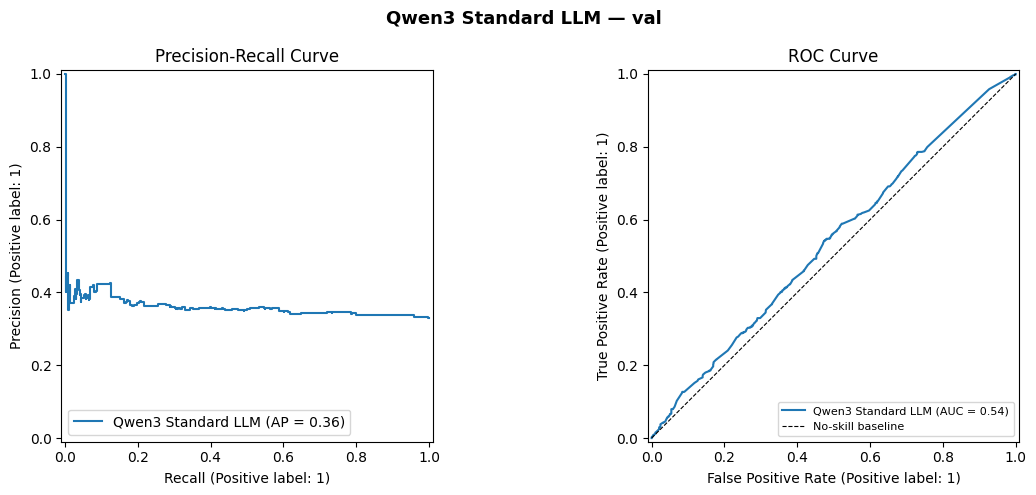

In [27]:
# Validation curves: PR-AUC and ROC
fig = plot_curves_summary(y_val, y_pred_val, y_prob_val, 'val', EVAL_DIR, model_name=MODEL_NAME)
ipy_display(fig)
plt.close(fig)


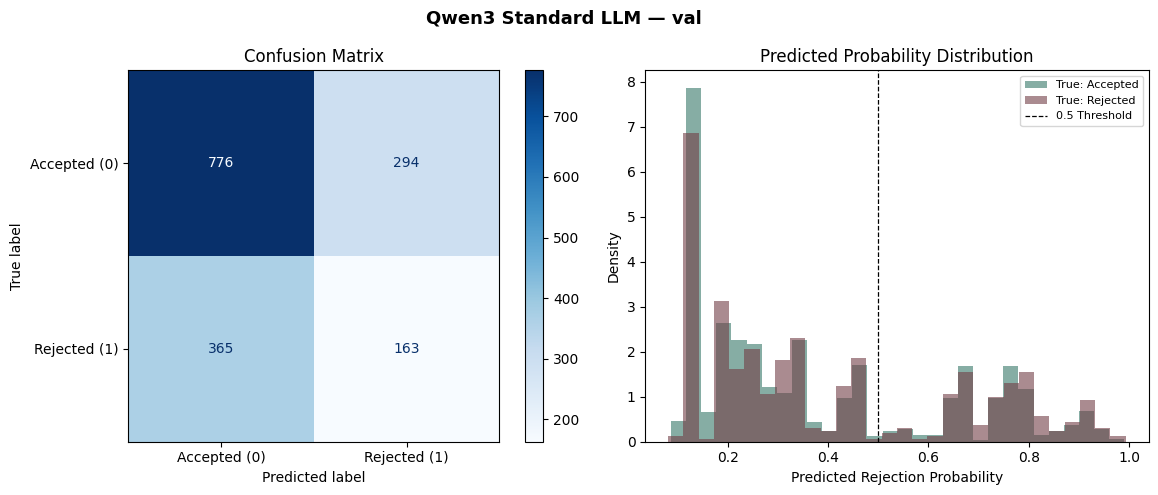

In [28]:
# Validation diagnostics: confusion matrix and probability distribution
fig = plot_diagnostics_summary(y_val, y_pred_val, y_prob_val, 'val', EVAL_DIR, model_name=MODEL_NAME)
ipy_display(fig)
plt.close(fig)


In [29]:
# Test metrics table
df_test_metrics = display_metric_table_test(test_metrics, EVAL_DIR, model_name=MODEL_NAME)


      PR-AUC  ROC-AUC  Precision  Recall  F1 (Class 1)  F1 Macro  Accuracy
Test  0.4242   0.5725     0.4196  0.3203        0.3633    0.5384    0.6049


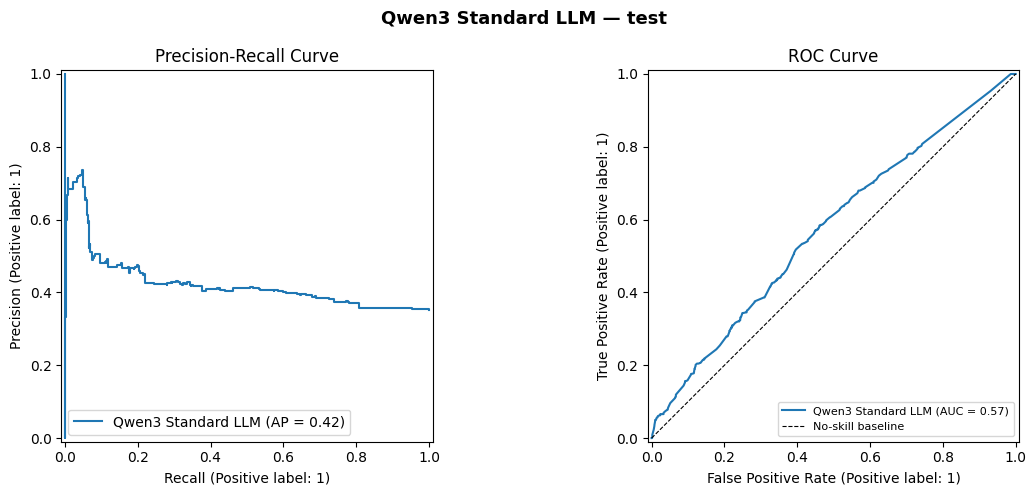

In [30]:
# Test curves: PR-AUC and ROC
fig = plot_curves_summary(y_test, y_pred_test, y_prob_test, 'test', EVAL_DIR, model_name=MODEL_NAME)
ipy_display(fig)
plt.close(fig)


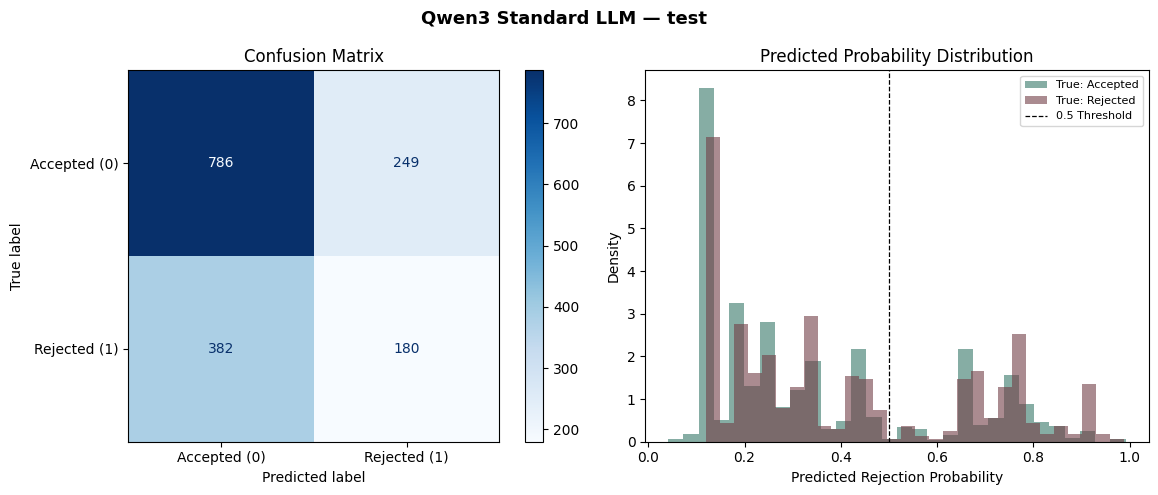

In [31]:
# Test diagnostics: confusion matrix and probability distribution
fig = plot_diagnostics_summary(y_test, y_pred_test, y_prob_test, 'test', EVAL_DIR, model_name=MODEL_NAME)
ipy_display(fig)
plt.close(fig)


In [32]:
# Val & test combined metrics table
combined_metrics = pd.concat([df_val_metrics, df_test_metrics]).T
print(combined_metrics.to_string())
combined_metrics.to_csv(EVAL_DIR / 'qwen3_standard_llm_metric_table_combined.csv')
print(f'Combined metrics table saved to {EVAL_DIR}/qwen3_standard_llm_metric_table_combined.csv')


              Validation    Test
PR-AUC            0.3603  0.4242
ROC-AUC           0.5370  0.5725
Precision         0.3567  0.4196
Recall            0.3087  0.3203
F1 (Class 1)      0.3310  0.3633
F1 Macro          0.5165  0.5384
Accuracy          0.5876  0.6049
Combined metrics table saved to /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/qwen3_standard_llm/qwen3_standard_llm_metric_table_combined.csv


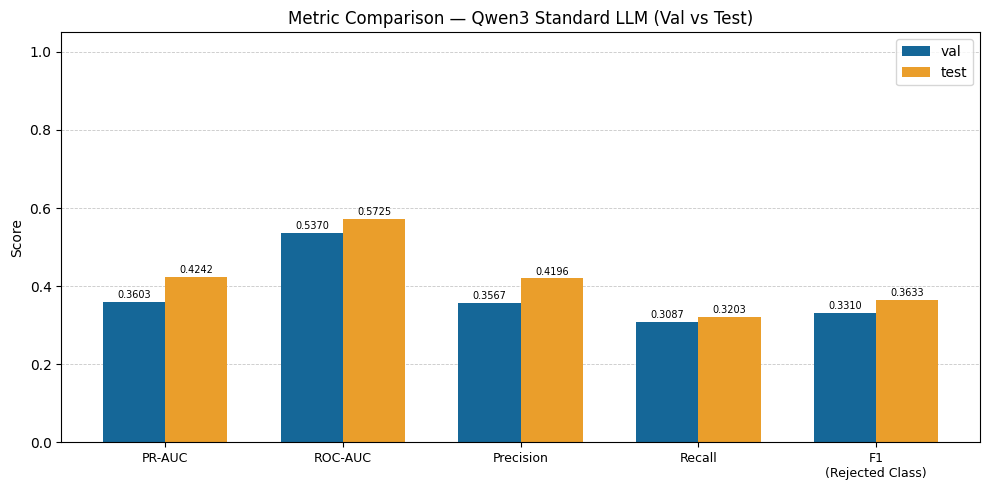

In [33]:
# Val vs test metric comparison chart
fig = plot_metric_bars(all_metrics, EVAL_DIR, model_name=MODEL_NAME)
ipy_display(fig)
plt.close(fig)


### Subgroup performance analyses

#### Validation subgroups by agent, task type, language, and diff size bin


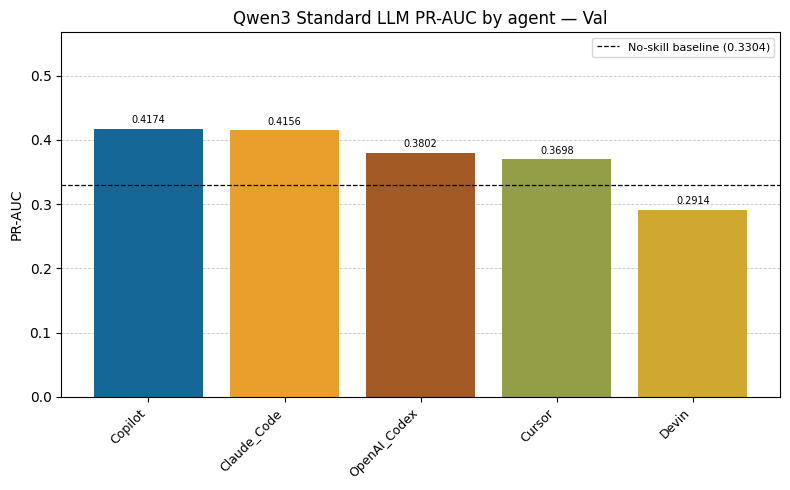

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
Copilot,536,0.386,0.4174,0.5268,0.4268,0.1691,0.2422,False
Claude_Code,42,0.381,0.4156,0.5529,0.3000,0.1875,0.2308,False
OpenAI_Codex,529,0.323,0.3802,0.5767,0.3797,0.4152,0.3966,False
Cursor,312,0.260,0.3698,0.5779,0.2869,0.4321,0.3448,False
Devin,179,0.296,0.2914,0.5183,0.3393,0.3585,0.3486,False


In [34]:
# Val subgroup analysis
val_merged = val_preds.merge(
    val_df[['id', 'agent', 'total_changes', 'language']].rename(columns={'id': 'pr_id'}),
    on='pr_id', how='left',
)

# Test subgroup: agent
_ = run_subgroup_report(
    val_merged['label'].values,
    val_merged['y_pred'].values,
    val_merged['rejection_probability'].values,
    group_cols={'agent': val_merged['agent'].fillna('unknown').values},
    eval_dir=EVAL_DIR, model_name=MODEL_NAME, split_name='val',
    filter_low_support_dims={'agent'},
    display_fn=ipy_display,
)

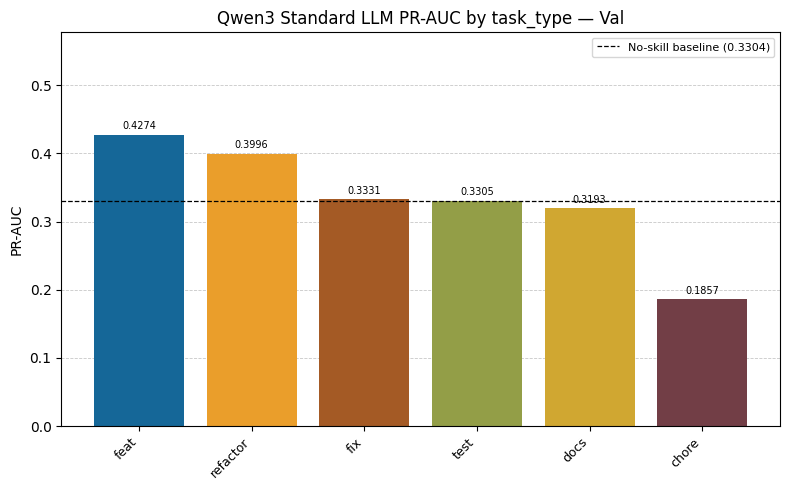

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
other,2,0.500,1.0000,1.0000,1.0000,1.0000,1.0000,True
perf,15,0.600,0.6243,0.4630,0.5714,0.4444,0.5000,True
ci,15,0.200,0.4444,0.8056,0.0000,0.0000,0.0000,True
build,29,0.345,0.4442,0.5605,0.2000,0.1000,0.1333,True
feat,605,0.392,0.4274,0.5055,0.3837,0.4177,0.4000,False
refactor,104,0.346,0.3996,0.4773,0.3125,0.2778,0.2941,False
fix,483,0.317,0.3331,0.5063,0.3333,0.2026,0.2520,False
test,84,0.321,0.3305,0.4825,0.3684,0.2593,0.3043,False
docs,190,0.195,0.3193,0.6073,0.5000,0.1351,0.2128,False
chore,62,0.242,0.1857,0.3376,0.1667,0.3333,0.2222,False


In [35]:
# Val subgroup: task type
_ = run_subgroup_report(
    val_merged['label'].values,
    val_merged['y_pred'].values,
    val_merged['rejection_probability'].values,
    group_cols={'task_type': _get_task_type(val_df)},
    eval_dir=EVAL_DIR, model_name=MODEL_NAME, split_name='val',
    filter_low_support_dims={'task_type'},
    display_fn=ipy_display,
)

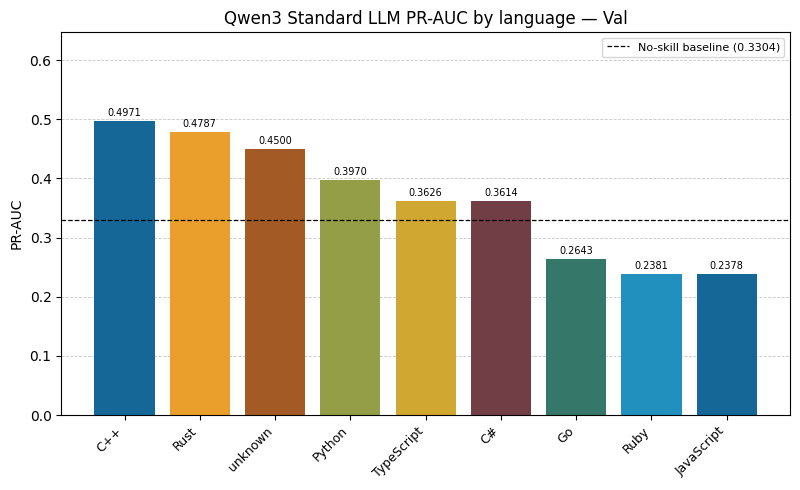

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
Kotlin,9,0.778,0.9643,0.8571,0.0000,0.0000,0.0000,True
PowerShell,4,0.750,0.8333,0.3333,1.0000,0.3333,0.5000,True
Circom,27,0.407,0.6864,0.7159,0.5714,0.3636,0.4444,True
PHP,8,0.375,0.6095,0.5667,1.0000,0.3333,0.5000,True
Vue,12,0.333,0.5833,0.5469,0.5000,0.5000,0.5000,True
Zig,5,0.600,0.5333,0.1667,0.3333,0.3333,0.3333,True
C,29,0.379,0.5287,0.6818,0.6667,0.1818,0.2857,True
Java,29,0.379,0.5094,0.5101,0.6000,0.2727,0.3750,True
Bicep,3,0.333,0.5000,0.5000,0.0000,0.0000,0.0000,True
F#,3,0.333,0.5000,0.5000,0.0000,0.0000,0.0000,True


In [36]:
# Val subgroup: language
_ = run_subgroup_report(
    val_merged['label'].values,
    val_merged['y_pred'].values,
    val_merged['rejection_probability'].values,
    group_cols={'language': val_merged['language'].fillna('unknown').values},
    eval_dir=EVAL_DIR, model_name=MODEL_NAME, split_name='val',
    top_n_dims={'language': 10},
    filter_low_support_dims={'language'},
    display_fn=ipy_display,
)

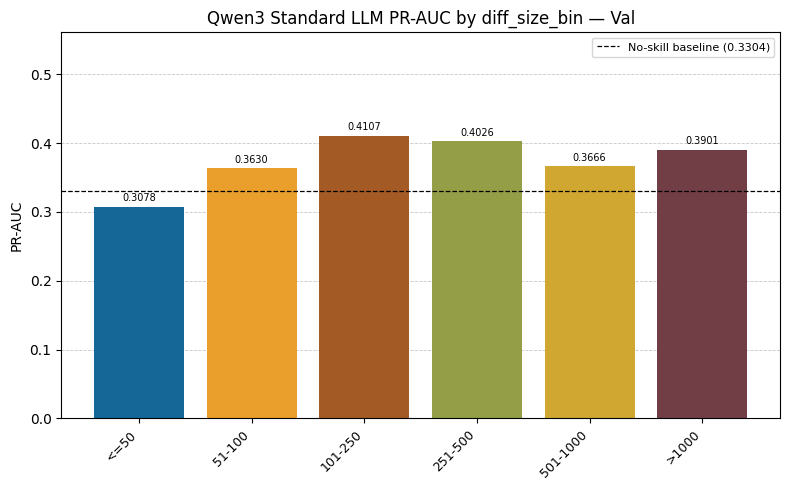

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
101-250,269,0.376,0.4107,0.5240,0.4118,0.2772,0.3314,False
251-500,193,0.342,0.4026,0.5299,0.3621,0.3182,0.3387,False
>1000,319,0.360,0.3901,0.5041,0.3614,0.5217,0.4270,False
501-1000,129,0.349,0.3666,0.5017,0.3333,0.3111,0.3218,False
51-100,180,0.361,0.3630,0.4617,0.2558,0.1692,0.2037,False
<=50,508,0.268,0.3078,0.5614,0.3625,0.2132,0.2685,False


Val subgroup charts saved to /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/qwen3_standard_llm


In [37]:
# Val subgroup: diff size
_ = run_subgroup_report(
    val_merged['label'].values,
    val_merged['y_pred'].values,
    val_merged['rejection_probability'].values,
    group_cols={'diff_size_bin': _diff_size_bin(val_merged['total_changes'])},
    eval_dir=EVAL_DIR, model_name=MODEL_NAME, split_name='val',
    category_orders={'diff_size_bin': _DIFF_LABELS},
    filter_low_support_dims={'diff_size_bin'},
    display_fn=ipy_display,
)
print('Val subgroup charts saved to', EVAL_DIR)

#### Test subgroups by agent, task type, language, and diff size bin


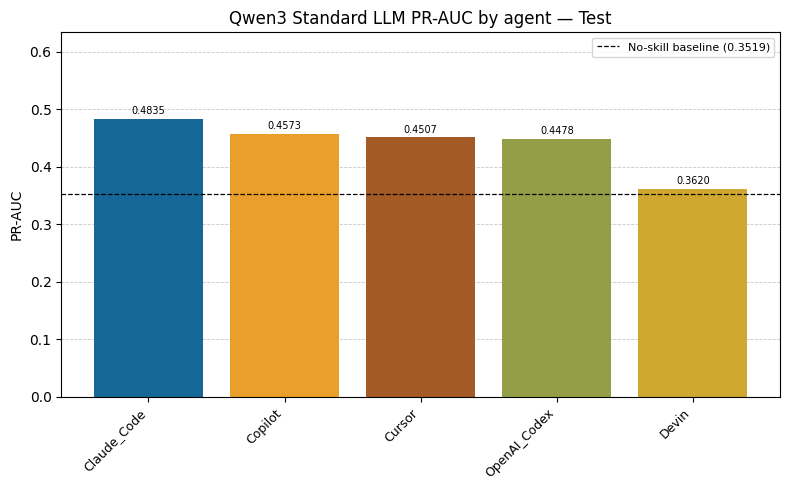

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
Claude_Code,62,0.419,0.4835,0.5454,0.3750,0.2308,0.2857,False
Copilot,480,0.419,0.4573,0.5260,0.4875,0.1940,0.2776,False
Cursor,256,0.289,0.4507,0.6600,0.4250,0.4595,0.4416,False
OpenAI_Codex,572,0.334,0.4478,0.5971,0.3980,0.4084,0.4031,False
Devin,227,0.308,0.3620,0.6093,0.4035,0.3286,0.3622,False


In [38]:
# Test subgroup analysis
test_merged = test_preds.merge(
    test_df[['id', 'agent', 'total_changes', 'language']].rename(columns={'id': 'pr_id'}),
    on='pr_id', how='left',
)

# Test subgroup: agent
_ = run_subgroup_report(
    test_merged['label'].values,
    test_merged['y_pred'].values,
    test_merged['rejection_probability'].values,
    group_cols={'agent': test_merged['agent'].fillna('unknown').values},
    eval_dir=EVAL_DIR, model_name=MODEL_NAME, split_name='test',
    filter_low_support_dims={'agent'},
    display_fn=ipy_display,
)

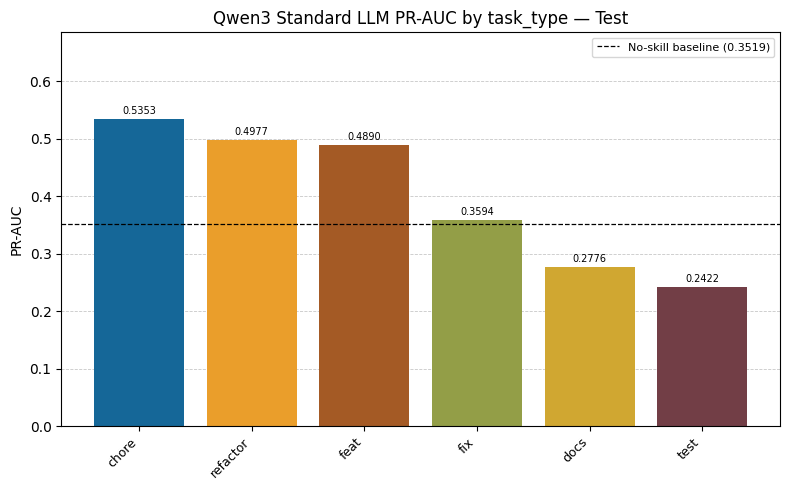

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
chore,36,0.361,0.5353,0.7023,0.5556,0.3846,0.4545,False
refactor,113,0.345,0.4977,0.6320,0.5278,0.4872,0.5067,False
feat,609,0.429,0.4890,0.5449,0.4588,0.4483,0.4535,False
build,25,0.240,0.4733,0.7018,0.5000,0.3333,0.4000,True
style,16,0.188,0.4429,0.7949,0.5000,0.3333,0.4000,True
fix,501,0.351,0.3594,0.4969,0.3133,0.1477,0.2008,False
docs,215,0.214,0.2776,0.5826,0.2667,0.0870,0.1311,False
perf,12,0.333,0.2649,0.1250,0.0000,0.0000,0.0000,True
test,43,0.233,0.2422,0.4424,0.2500,0.3000,0.2727,False
ci,21,0.048,0.1000,0.5500,0.0000,0.0000,0.0000,True


In [39]:
# Test subgroup: task type
_ = run_subgroup_report(
    test_merged['label'].values,
    test_merged['y_pred'].values,
    test_merged['rejection_probability'].values,
    group_cols={'task_type': _get_task_type(test_df)},
    eval_dir=EVAL_DIR, model_name=MODEL_NAME, split_name='test',
    filter_low_support_dims={'task_type'},
    display_fn=ipy_display,
)

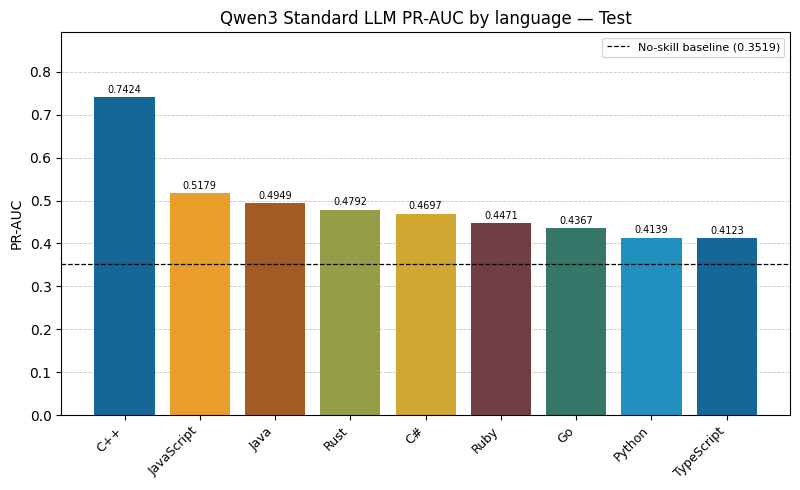

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
Vue,4,0.250,1.0000,1.0000,0.2500,1.0000,0.4000,True
Julia,3,0.667,1.0000,1.0000,1.0000,0.5000,0.6667,True
Kotlin,11,0.727,0.8644,0.7083,0.8333,0.6250,0.7143,True
C++,42,0.476,0.7424,0.6477,1.0000,0.3500,0.5185,False
Swift,12,0.500,0.6758,0.5000,1.0000,0.3333,0.5000,True
Bicep,7,0.571,0.6179,0.2500,1.0000,0.2500,0.4000,True
PHP,8,0.500,0.5893,0.3125,0.5000,0.2500,0.3333,True
C,24,0.333,0.5472,0.5664,0.4286,0.3750,0.4000,True
Circom,15,0.533,0.5228,0.5000,0.0000,0.0000,0.0000,True
JavaScript,50,0.260,0.5179,0.6559,0.3333,0.5385,0.4118,False


In [40]:
# Test subgroup: language
_ = run_subgroup_report(
    test_merged['label'].values,
    test_merged['y_pred'].values,
    test_merged['rejection_probability'].values,
    group_cols={'language': test_merged['language'].fillna('unknown').values},
    eval_dir=EVAL_DIR, model_name=MODEL_NAME, split_name='test',
    top_n_dims={'language': 10},
    filter_low_support_dims={'language'},
    display_fn=ipy_display,
)

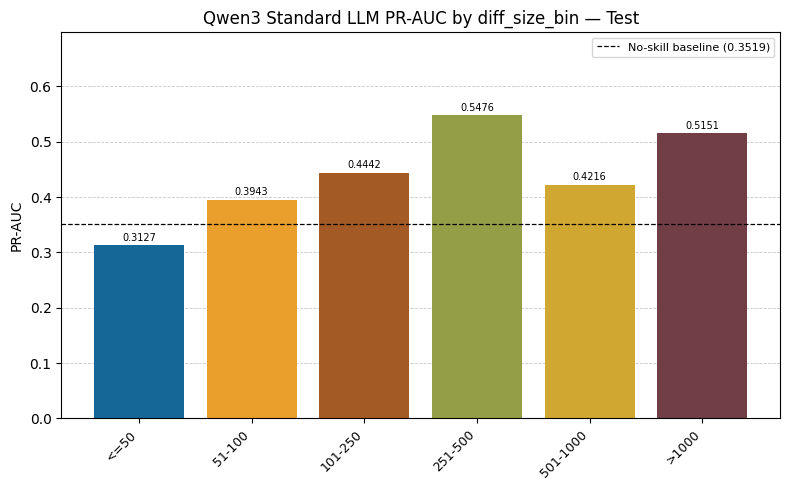

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
251-500,175,0.463,0.5476,0.5615,0.5918,0.3580,0.4462,False
>1000,267,0.412,0.5151,0.5453,0.4054,0.5455,0.4651,False
101-250,286,0.402,0.4442,0.5695,0.3934,0.2087,0.2727,False
501-1000,137,0.365,0.4216,0.5105,0.3571,0.4000,0.3774,False
51-100,221,0.330,0.3943,0.5392,0.3922,0.2740,0.3226,False
<=50,511,0.260,0.3127,0.5470,0.4219,0.2030,0.2741,False


In [41]:
# Test subgroup: diff size
_ = run_subgroup_report(
    test_merged['label'].values,
    test_merged['y_pred'].values,
    test_merged['rejection_probability'].values,
    group_cols={'diff_size_bin': _diff_size_bin(test_merged['total_changes'])},
    eval_dir=EVAL_DIR, model_name=MODEL_NAME, split_name='test',
    category_orders={'diff_size_bin': _DIFF_LABELS},
    filter_low_support_dims={'diff_size_bin'},
    display_fn=ipy_display,
)